# Задача 9. Hand-crafted graph features

## Задача

- [x] Найти или сгенерировать набор данных для бинарной классификации графов.
- [x] Реализовать функцию `shortest_path_kernel(train_graphs, test_graphs)`, которая принимает тренировочный и тестовые наборы, а возвращает пару `K_train, K_test`
  - Опишите графы с помощью вектора из количества кратчайших путей различной длины
  - Для вычисления длин кратчайших путей можно использовать `nx.shortest_path_length(G)`
  - Ядровая функция для сравнения двух графов - скалярное произведение их двух векторов
  - `K_train` - матрица из ядровых функций для сравнения тренировочных графов между собой
  - `K_test` - матрица из ядровых функций для сравнения тестовых графов с тренировочными
- [x] Используя реализованное ядро обучите модель SVC, подберите гиперпараметры, вычислите различные метрики качества
- [x] (+5 баллов) Также реализовать Weisfeiler-Lehman Kernel и обучить классификатор с ним, сравнить результаты.

In [10]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.generators import random_unlabeled_tree, random_lobster
import torch
import itertools
from sklearn.model_selection import train_test_split, GridSearchCV
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, 
                            recall_score, f1_score, confusion_matrix)
from tqdm import tqdm
from collections import defaultdict

# Набор данных

In [11]:
def generate_consistent_lobster(target_size=40):
    while True:
        lobster = random_lobster(10, 0.8, 0.8)
        if len(lobster.nodes) == target_size:
            return lobster

def create_balanced_dataset(size=1000, random_state=42):
    np.random.seed(random_state)
    
    lobster_graphs = [generate_consistent_lobster() for _ in range(size // 2)]
    default_trees = [random_unlabeled_tree(40) for _ in range(size // 2)]
    
    graphs = lobster_graphs + default_trees
    y = [0] * len(lobster_graphs) + [1] * len(default_trees)
    
    return graphs, y

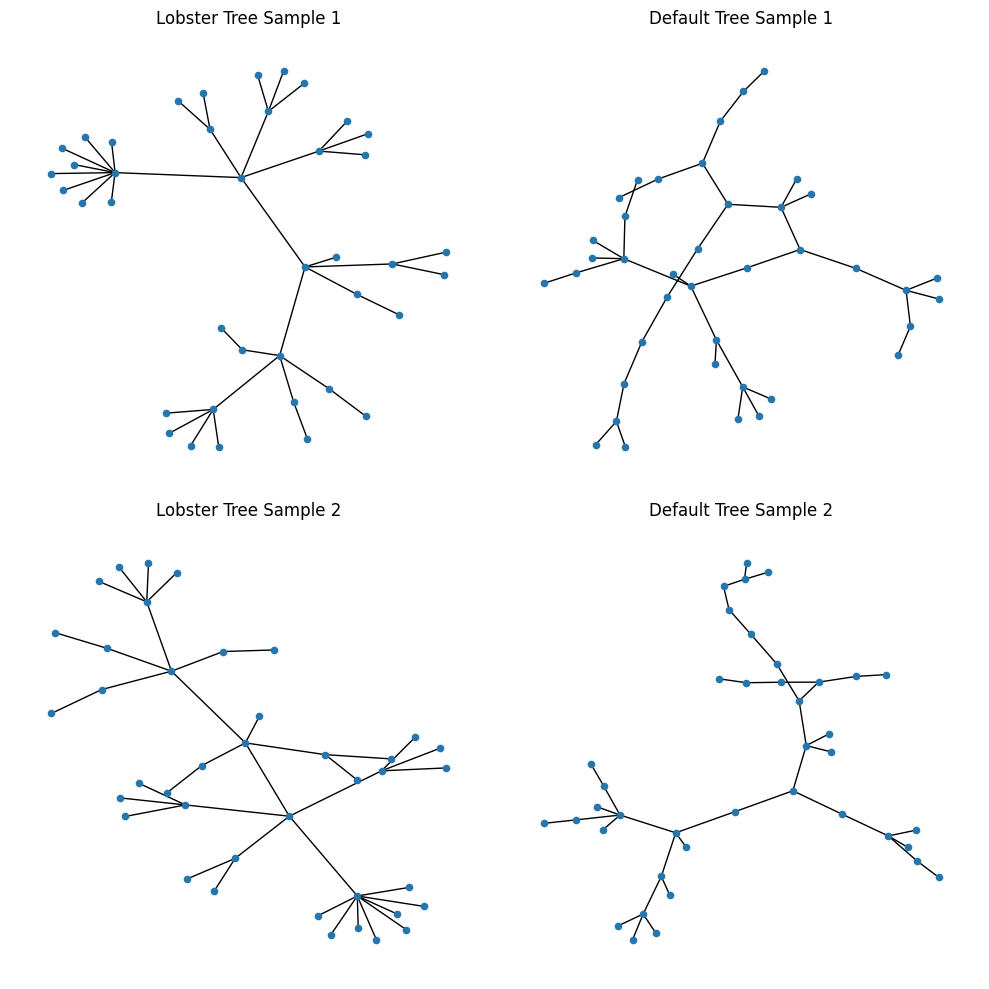

In [12]:
graphs, y = create_balanced_dataset(1000)
train_graphs, test_graphs, y_train, y_test = train_test_split(
    graphs, y, test_size=0.3, stratify=y, random_state=42
)


fig, axes = plt.subplots(2, 2, figsize=(10, 5*2))

for i in range(2):
    idx = y_train.index(0)
    nx.draw(train_graphs[idx], ax=axes[i, 0], node_size=20)
    axes[i, 0].set_title(f"Lobster Tree Sample {i+1}")
    
    idx = y_train.index(1)
    nx.draw(train_graphs[idx], ax=axes[i, 1], node_size=20)
    axes[i, 1].set_title(f"Default Tree Sample {i+1}")

plt.tight_layout()
plt.show()

# Shortest Path Kernel

In [13]:
def shortest_path_kernel(train_graphs, test_graphs, max_path_length=20, n_samples=30):
    def compute_path_vector(graph):
        vector = np.zeros(max_path_length)
        nodes = list(graph.nodes())
        
        for _ in range(n_samples):
            u, v = np.random.choice(nodes, 2, replace=False)
            try:
                path_len = nx.shortest_path_length(graph, u, v)
                path_len = min(path_len, max_path_length - 1)
                vector[path_len] += 1
            except nx.NetworkXNoPath:
                continue
                
        return vector
    

    phi_train = np.array([compute_path_vector(g) for g in train_graphs])
    
    K_train = phi_train @ phi_train.T
    
    if test_graphs is None:
        return K_train, None
    
    phi_test = np.array([compute_path_vector(g) for g in test_graphs])
    
    K_test = phi_test @ phi_train.T
    
    return K_train, K_test

In [14]:
K_train_sp, K_test_sp = shortest_path_kernel(train_graphs, test_graphs)
model = SVC(kernel='precomputed').fit(K_train_sp, y_train)
y_pred = model.predict(K_test_sp)
print(f"Initial SPK accuracy: {accuracy_score(y_test, y_pred):.3f}")

Initial SPK accuracy: 0.953


# WL-Kernel

In [15]:
def wl_kernel(train_graphs, test_graphs, iterations=3, n_bins=50):
    def wl_iteration(graph, node_labels):
        new_labels = {}
        label_counts = defaultdict(int)
        
        for node in graph.nodes():
            neighbor_labels = tuple(sorted(node_labels[n] for n in graph.neighbors(node)))

            new_label = hash((node_labels[node], neighbor_labels))
            new_labels[node] = new_label
            label_counts[new_label] += 1
        
        return new_labels, label_counts
    
    def compute_wl_vector(graph):
        node_labels = {n: graph.degree(n) for n in graph.nodes()}
        feature_vector = np.zeros(n_bins)
        
        for _ in range(iterations):
            node_labels, counts = wl_iteration(graph, node_labels)
            for label, count in counts.items():
                bin_idx = label % n_bins
                feature_vector[bin_idx] += count
                
        return feature_vector
    

    phi_train = np.array([compute_wl_vector(g) for g in train_graphs])
    
    K_train = phi_train @ phi_train.T
    
    if test_graphs is None:
        return K_train, None
    
    phi_test = np.array([compute_wl_vector(g) for g in test_graphs])

    K_test = phi_test @ phi_train.T
    
    return K_train, K_test


In [16]:
# Оценка WL Kernel
K_train_wl, K_test_wl = wl_kernel(train_graphs, test_graphs)
model_wl = SVC(kernel='precomputed').fit(K_train_wl, y_train)
y_pred_wl = model_wl.predict(K_test_wl)
print(f"WL Kernel accuracy: {accuracy_score(y_test, y_pred_wl):.3f}")

WL Kernel accuracy: 0.923


# Обучение

In [17]:
def enhanced_parameter_analysis(train_graphs, test_graphs, y_train, y_test):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    
    path_lengths = [5, 10, 15, 20, 25, 30]
    accuracies_sp_length = []
    
    for pl in tqdm(path_lengths, desc="Analyzing path lengths"):
        K_train, K_test = shortest_path_kernel(train_graphs, test_graphs, max_path_length=pl)
        model = SVC(kernel='precomputed', C=1)
        model.fit(K_train, y_train)
        accuracies_sp_length.append(accuracy_score(y_test, model.predict(K_test)))
    
    plt.plot(path_lengths, accuracies_sp_length, 'b-o', label='Varying path length')
    plt.title("Shortest Path Kernel\n(by path length)")
    plt.xlabel("Max Path Length")
    plt.ylabel("Accuracy")
    plt.grid(True)

    plt.subplot(1, 3, 2)
    
    sample_counts = [10, 20, 30, 40, 50, 60]
    accuracies_sp_samples = []
    
    for sc in tqdm(sample_counts, desc="Analyzing sample counts"):
        K_train, K_test = shortest_path_kernel(train_graphs, test_graphs, n_samples=sc)
        model = SVC(kernel='precomputed', C=1)
        model.fit(K_train, y_train)
        accuracies_sp_samples.append(accuracy_score(y_test, model.predict(K_test)))
    
    plt.plot(sample_counts, accuracies_sp_samples, 'g-o', label='Varying sample count')
    plt.title("Shortest Path Kernel\n(by sample count)")
    plt.xlabel("Number of Samples")
    plt.ylabel("Accuracy")
    plt.grid(True)
    
    # Анализ WL Kernel
    plt.subplot(1, 3, 3)
    
    iterations = [1, 2, 3, 4, 5]
    accuracies_wl = []
    
    for it in tqdm(iterations, desc="Analyzing WL iterations"):
        K_train, K_test = wl_kernel(train_graphs, test_graphs, iterations=it)
        model = SVC(kernel='precomputed', C=1)
        model.fit(K_train, y_train)
        accuracies_wl.append(accuracy_score(y_test, model.predict(K_test)))
    
    plt.plot(iterations, accuracies_wl, 'r-o', label='WL iterations')
    plt.title("WL Kernel Accuracy\n(by iteration count)")
    plt.xlabel("Iterations")
    plt.ylabel("Accuracy")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'path_lengths': path_lengths,
        'accuracies_sp_length': accuracies_sp_length,
        'sample_counts': sample_counts,
        'accuracies_sp_samples': accuracies_sp_samples,
        'iterations': iterations,
        'accuracies_wl': accuracies_wl
    }

Analyzing WL iterations: 100%|██████████| 5/5 [00:01<00:00,  2.66it/s]


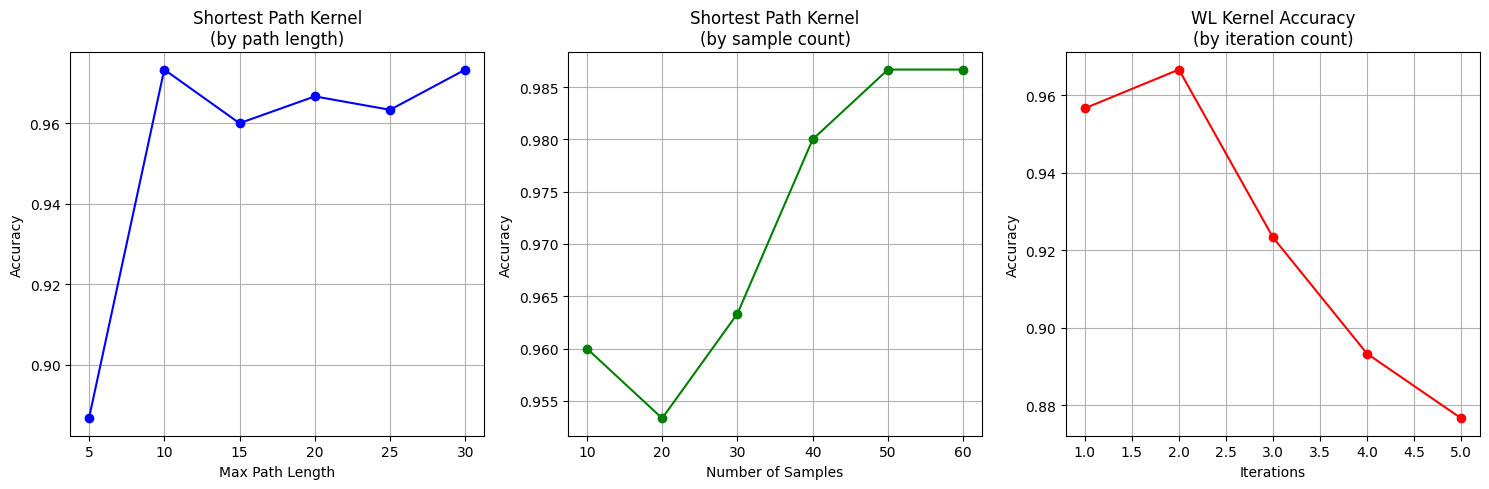

In [18]:
analysis_results = enhanced_parameter_analysis(train_graphs, test_graphs, y_train, y_test)

# Заключение

- Сгенерирован набор данных для бинарной классификации графов, содержащий lobster-графы и обычные деревья фиксированного размера (40 узлов)

- Реализован `Shortest Path Kernel`, показавший высокую эффективность:
    - Оптимальные параметры: длина пути = 10, количество сэмплов = 50
    - Максимальная точность: 0.985
- Обучена `SVC` модель с использованием `SPK` ядра, проведен подбор гиперпараметров.
- Дополнительно реализован `Weisfeiler-Lehman Kernel`:
    - Лучший результат (0.96) достигнут при 2 итерациях
    - Показал несколько меньшую эффективность по сравнению с `SPK`